In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import MACCSkeys

In [2]:
from mordred import Calculator, descriptors

In [3]:
import matplotlib.pyplot as plt

In [4]:
df1 = pd.read_csv('./ido1_tdo_fulljoin_20260205.csv', na_values=['na'])
#df1 = df1.dropna(ignore_index=True)
df1

,molecule_chembl_id,smiles,ido1_ic50,tdo_ic50
0,CHEMBL412131,Cc1c(SC[C@H](NC(=O)CC[C@H](N)C(=O)O)C(=O)NCC(=...,340.0,NaN
1,CHEMBL565489,Cc1cccc(N/C(=N\O)c2nonc2N)c1,550.0,NaN
2,CHEMBL107103,O=C(c1ccccc1)c1cccc(O)c1,500000.0,NaN
3,CHEMBL3342385,CCOC(=O)c1cnc2scc(C3=CCCCC3)n12,100000.0,NaN
4,CHEMBL3765545,O=C1CCc2cc(S(=O)(=O)NNc3ccc(Br)cc3)ccc2N1,72.7,NaN
...,...,...,...,...
4586,CHEMBL6053460,N#Cc1cc(-c2c[nH]c3cc(F)ccc23)ccc1S(=O)(=O)N1CC...,NaN,730.0
4587,CHEMBL5819188,NC(=O)CNc1ccc(-c2c[nH]c3cc(F)ccc23)cn1,NaN,790.0
4588,CHEMBL4849018,OCC(O)Cn1nnc2ccc(-c3c[nH]c4ccccc34)cc21,NaN,25200.0
4589,CHEMBL4176841,Cc1ccn(-c2cnoc2N)n1,NaN,1600.0


In [5]:
df11 = df1.loc[:10, ['smiles','ido1_ic50']]
df11.to_csv('new_set.csv', index=False)

In [6]:
df11

,smiles,ido1_ic50
0,Cc1c(SC[C@H](NC(=O)CC[C@H](N)C(=O)O)C(=O)NCC(=...,340.0
1,Cc1cccc(N/C(=N\O)c2nonc2N)c1,550.0
2,O=C(c1ccccc1)c1cccc(O)c1,500000.0
3,CCOC(=O)c1cnc2scc(C3=CCCCC3)n12,100000.0
4,O=C1CCc2cc(S(=O)(=O)NNc3ccc(Br)cc3)ccc2N1,72.7
5,Oc1ccc(-c2[nH]cnc2-c2ccccc2)cc1O,6300.0
6,Oc1ccc(F)c(-c2cncn2CCNc2cccc3ccccc23)c1F,30000.0
7,N#Cc1c(-c2ccc(F)cc2)c2c(=O)[nH]c(=O)[nH]c2[nH]...,1149.0
8,N#Cc1c(-c2ccc(Br)cc2)c2c(=O)[nH]c(=O)[nH]c2[nH...,790.0
9,N#Cc1c(-c2ccc(F)c(Cl)c2)c2c(=O)[nH]c(=O)[nH]c2...,362.0


In [7]:
df2 = df1.loc[:, ['ido1_ic50', 'tdo_ic50']]
df2

,ido1_ic50,tdo_ic50
0,340.0,NaN
1,550.0,NaN
2,500000.0,NaN
3,100000.0,NaN
4,72.7,NaN
...,...,...
4586,NaN,730.0
4587,NaN,790.0
4588,NaN,25200.0
4589,NaN,1600.0


In [8]:
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] <= 1000:
        df2.loc[i, ['ido1_ic50']] = 1
    elif df2['ido1_ic50'].values[i] > 1000:
        df2.loc[i, ['ido1_ic50']] = 0
    else:
        df2.loc[i, ['ido1_ic50']] = np.nan

In [9]:
for i in range(len(df2)):
    if df2['tdo_ic50'].values[i] <= 1000:
        df2.loc[i, ['tdo_ic50']] = 1
    elif df2['tdo_ic50'].values[i] > 1000:
        df2.loc[i, ['tdo_ic50']] = 0
    else:
        df2.loc[i, ['tdo_ic50']] = np.nan

In [10]:
df2

,ido1_ic50,tdo_ic50
0,1.0,NaN
1,1.0,NaN
2,0.0,NaN
3,0.0,NaN
4,1.0,NaN
...,...,...
4586,NaN,1.0
4587,NaN,1.0
4588,NaN,0.0
4589,NaN,0.0


In [11]:
newcol = []
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('AA')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('II')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('IA')
    elif df2['ido1_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('AI')
    else:
        newcol.append(np.nan)

In [12]:
len(newcol)

4591

In [13]:
target = pd.DataFrame(data=newcol, columns=['ido_tdo'])
target

,ido_tdo
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4586,NaN
4587,NaN
4588,NaN
4589,NaN


In [14]:
y = target.values.reshape(len(df2),)
y.shape

(4591,)

In [15]:
#Identify labeled nodes
# Boolean mask for labeled nodes
labeled_mask = target['ido_tdo'].notna()

# Get indices of labeled nodes
labeled_indices = target.index[labeled_mask].to_numpy()  # 1126 nodes


In [16]:
labeled_indices.shape

(1126,)

In [17]:
#Shuffle and split
np.random.seed(42)  # for reproducibility
np.random.shuffle(labeled_indices)

n_total = len(labeled_indices)
n_train = int(0.6 * n_total)
n_val = int(0.2 * n_total)
n_test = n_total - n_train - n_val  # remaining

train_idx = labeled_indices[:n_train]
val_idx = labeled_indices[n_train:n_train + n_val]
test_idx = labeled_indices[n_train + n_val:]


In [18]:
len(train_idx), len(val_idx), len(test_idx)

(675, 225, 226)

In [19]:
import torch

In [20]:
#Create PyG masks
num_nodes = len(target)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True


In [21]:
train_mask.size(), test_mask.size()

(torch.Size([4591]), torch.Size([4591]))

In [22]:
train_idx.shape

(675,)

In [23]:
from rdkit.Chem import SaltRemover as sr
remover = sr.SaltRemover()

In [24]:
mols = []
for i in range(len(df1)):
    try:
        mol_i = Chem.MolFromSmiles(df1['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols.append(mol_i)
    except Exception as e:
        print(e)
len(mols)

4591

In [25]:
smiles_list = [df1['smiles'][i] for i in range(len(df1['smiles']))]

In [26]:
names_list = [df1['molecule_chembl_id'][i] for i in range(len(df1['molecule_chembl_id']))]

In [ ]:
#Deprecated method for Morgan as ExplicitBitVect
FPs = [AllChem.GetMorganFingerprintAsBitVect(mols[i], radius=3, nBits=1024) for i in range(len(mols))]

In [29]:
similarity_matrix = np.zeros((len(FPs), len(FPs)))

In [30]:
similarity_matrix.shape

(4591, 4591)

In [31]:
#Calculate the diagonal elements
for i in range(len(FPs)):
    for j in range(i, len(FPs)):  # Avoid duplicate calculations
        similarity = DataStructs.TanimotoSimilarity(FPs[i], FPs[j])
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

In [32]:
similarity_matrix.shape

(4591, 4591)

In [39]:
import seaborn as sns

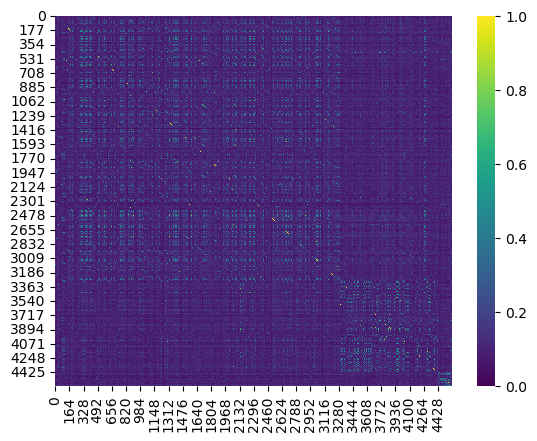

In [40]:
#Tanimoto
sns.heatmap(similarity_matrix, cmap='viridis');

In [33]:
similarity_matrix.min(), similarity_matrix.max(), similarity_matrix.mean()

(0.0, 1.0, 0.11476852948471082)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x782610a3a0f0>],
 'cmeans': <matplotlib.collections.LineCollection at 0x782610a4cb30>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x78261069d970>,
 'cmins': <matplotlib.collections.LineCollection at 0x782610a4dee0>,
 'cbars': <matplotlib.collections.LineCollection at 0x78261069d760>,
 'cmedians': <matplotlib.collections.LineCollection at 0x78261069ee40>}

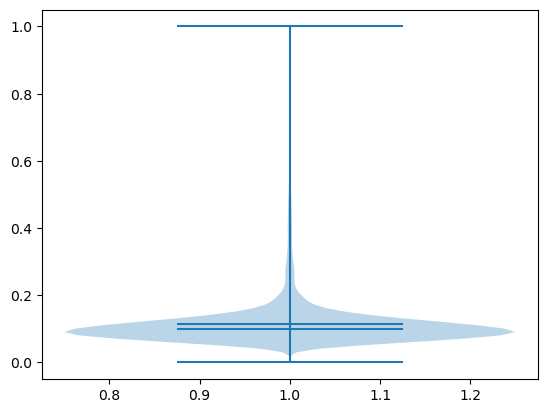

In [34]:
#Tanimoto
plt.violinplot(similarity_matrix.flatten(), showmeans=True, showmedians=True)

In [35]:
import networkx as nx

In [36]:
#Build k-NN graph from similarity matrix
k = 15  # start with 10–20

In [37]:
#(Recommended) Mutual k-NN
#This avoids hubs:
max_w = np.max(similarity_matrix ** 2)
edges = set()
num_nodes = similarity_matrix.shape[0]
for i in range(num_nodes):
    sims = similarity_matrix[i]
    nn_idx = np.argsort(sims)[::-1][1:k+1]
    for j in nn_idx:
        edges.add((i, j))

G = nx.Graph()
for i, j in edges:
    if (j, i) in edges:
        w = (similarity_matrix[i, j]**2) / max_w
        G.add_edge(i, j, weight=w)

In [38]:
len(G.nodes), len(G.edges)

(4510, 22254)

In [39]:
G.number_of_nodes(), G.number_of_edges()

(4510, 22254)

In [36]:
#To save the graph:
nx.write_graphml(G, "graph_idotdo_5491.graphml")

(-0.2, -0.1)

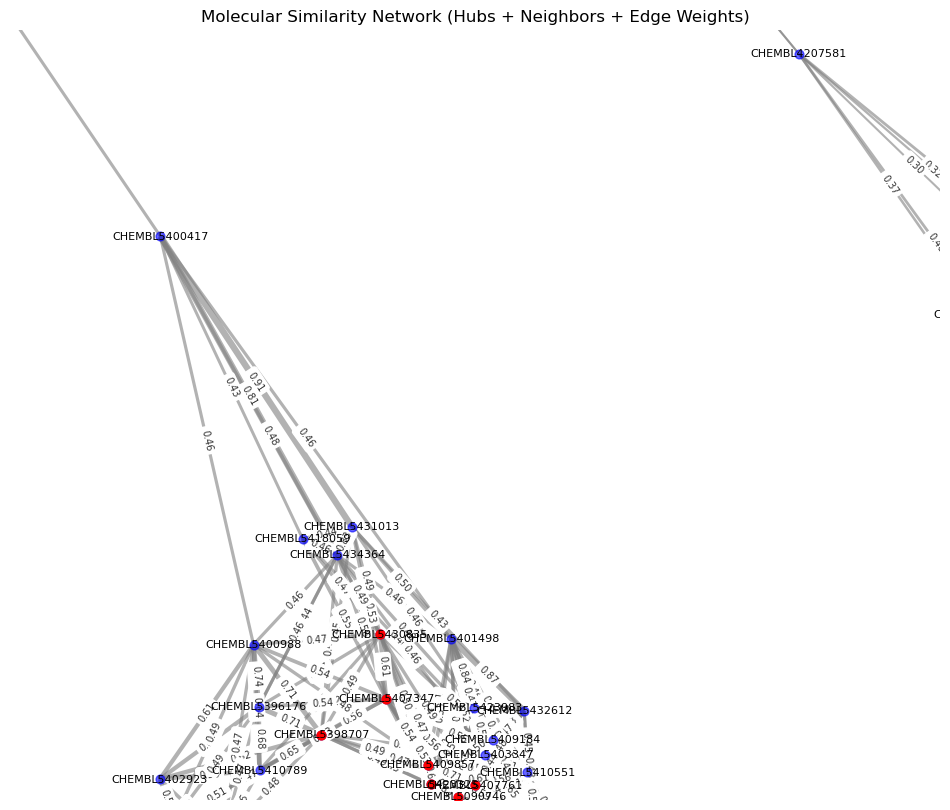

In [49]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 10))

# Work on a copy
G_clean = G.copy()
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))

# Degree dictionary
degree_dict = dict(G_clean.degree())

# Select high-degree nodes
high_degree_nodes = [n for n, d in degree_dict.items() if d > 14]

# Neighbors of high-degree nodes
neighbor_nodes = set()
for node in high_degree_nodes:
    neighbor_nodes.update(G_clean.neighbors(node))

# Nodes to draw
nodes_to_draw = set(high_degree_nodes) | neighbor_nodes

# Subgraph
H = G_clean.subgraph(nodes_to_draw)

# Layout
pos = nx.spring_layout(H, seed=42)

# --- Draw edges with width proportional to weight ---
edges = H.edges(data=True)
edge_weights = [d['weight']*5 for u, v, d in edges]  # scale for visibility
nx.draw_networkx_edges(
    H,
    pos,
    width=edge_weights,
    edge_color="gray",
    alpha=0.6
)

# --- Draw nodes ---
nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=list(neighbor_nodes),
    node_size=40,
    node_color="blue",
    alpha=0.6
)

nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=high_degree_nodes,
    node_size=40,
    node_color="red"
)

# --- Node labels ---
label_dict = {i: names_list[i] for i in H.nodes()}
nx.draw_networkx_labels(H, pos, labels=label_dict, font_size=8)

# --- Edge weight labels ---
# Create dictionary: key=(u,v), value=weight (rounded)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in H.edges(data=True)}

nx.draw_networkx_edge_labels(
    H,
    pos,
    edge_labels=edge_labels,
    font_size=7,
    label_pos=0.5,   # position along edge (0=start, 0.5=center)
    rotate=True,
    alpha=0.8
)

plt.title("Molecular Similarity Network (Hubs + Neighbors + Edge Weights)")
plt.axis("off")
plt.xlim(-0.2, -0.1)
plt.ylim(-0.2, -0.1)
#plt.show()
# Or save
plt.savefig("network_with_edge_weights.png", dpi=300, bbox_inches="tight")

In [40]:
G.is_directed()

False

In [41]:
G.number_of_edges(), G.number_of_nodes()

(22254, 4510)

In [42]:
#Step 1: Compute Morgan fingerprints

In [43]:
# Suppose you have a list of SMILES strings for your dataset
def morgan_fp(smiles, radius=2, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    fpgen = AllChem.GetMorganGenerator(fpSize=1024)
    arr_fp = fpgen.GetFingerprintAsNumPy(mol)
    return arr_fp

node_features = np.array([morgan_fp(s) for s in smiles_list])  # shape (4591, 1024)

In [44]:
node_features.shape

(4591, 1024)

In [45]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=256, random_state=42)
X = svd.fit_transform(node_features)

In [46]:
#For PyG, node labels should be integers (0–3 for 4 classes).
# Map class names to integers
class_mapping = {'AA': 0, 'AI': 1, 'IA': 2, 'II': 3}
labels = target['ido_tdo'].map(class_mapping)

# Replace NaN with -1 (unlabeled)
labels = labels.fillna(-1).astype(int)

y = torch.tensor(labels.values, dtype=torch.long)

In [47]:
y

tensor([-1, -1, -1,  ..., -1, -1, -1])

In [48]:
X.shape

(4591, 256)

In [49]:
#In the following steps, we are preparing and converting the data to a pytorch compatible input data.

In [50]:
#Step 2: Build edge list with weights from NetworkX

In [51]:
import torch
from torch_geometric.data import Data

# Assume G is your weighted NetworkX graph
edge_index = []
edge_attr = []

for u, v, data in G.edges(data=True):
    edge_index.append([u, v])
    edge_index.append([v, u])  # undirected graph → add both directions
    edge_attr.append([data['weight']])
    edge_attr.append([data['weight']])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()  # shape [2, num_edges]
edge_attr = torch.tensor(edge_attr, dtype=torch.float)                   # shape [num_edges, 1]

In [52]:
#Step 3: Add node features and labels

In [53]:
# Convert node features to tensor
x = torch.tensor(X, dtype=torch.float)  # shape [4591, 1024]

In [54]:
#Step 4: Create PyTorch Geometric Data object

In [55]:
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

print(data)
# Data(x=[760, 2048], edge_index=[2, num_edges], edge_attr=[num_edges, 1], y=[760])

Data(x=[4591, 256], edge_index=[2, 44508], edge_attr=[44508, 1], y=[4591])


**How to create train_mask, val_mask, test_mask**

Since you have one graph with 4591 nodes, 
you need to split the nodes into train/validation/test sets. 
Each mask is a boolean tensor of shape [num_nodes] where True means that node belongs to that split.

In [56]:
data.edge_attr.shape

torch.Size([44508, 1])

In [57]:
# Attach to data object
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

In [58]:
data.train_mask.sum()

tensor(675)

In [59]:
# Assuming your Data object is already built with x, edge_index, edge_attr, y

print("Train nodes:", data.train_mask.sum().item())
print("Val nodes:", data.val_mask.sum().item())
print("Test nodes:", data.test_mask.sum().item())

Train nodes: 675
Val nodes: 225
Test nodes: 226


In [60]:
data.y[data.test_mask]

tensor([1, 2, 1, 1, 1, 0, 3, 0, 1, 0, 3, 0, 1, 1, 0, 0, 0, 0, 3, 1, 0, 3, 2, 3,
        0, 3, 0, 3, 1, 0, 0, 0, 1, 0, 2, 3, 1, 2, 3, 0, 3, 0, 0, 3, 1, 2, 0, 1,
        0, 3, 1, 3, 1, 3, 1, 0, 1, 0, 2, 1, 2, 0, 0, 1, 3, 0, 3, 0, 1, 3, 0, 0,
        1, 0, 3, 0, 0, 1, 1, 1, 0, 0, 3, 1, 2, 2, 3, 0, 1, 0, 0, 1, 0, 1, 0, 1,
        1, 0, 0, 3, 3, 3, 0, 1, 1, 0, 2, 1, 3, 2, 0, 1, 1, 1, 3, 1, 3, 1, 1, 3,
        0, 0, 0, 1, 0, 3, 1, 3, 3, 1, 1, 0, 0, 1, 1, 3, 3, 1, 0, 1, 0, 0, 3, 1,
        1, 1, 0, 0, 1, 1, 1, 2, 0, 0, 0, 0, 0, 3, 1, 0, 1, 1, 0, 0, 1, 3, 1, 3,
        2, 0, 1, 0, 3, 3, 1, 3, 1, 0, 1, 3, 0, 0, 0, 0, 0, 1, 1, 3, 3, 0, 1, 0,
        3, 1, 3, 1, 0, 0, 0, 1, 0, 1, 2, 0, 3, 3, 1, 0, 1, 3, 0, 0, 3, 0, 0, 0,
        1, 3, 0, 1, 1, 0, 3, 0, 0, 3])

In [61]:
data.x[test_mask].shape

torch.Size([226, 256])

In [62]:
data.x[train_mask]

tensor([[ 2.7838, -2.0381,  2.2777,  ...,  0.1650,  0.2507, -0.0518],
        [ 3.0613, -1.5183,  0.3860,  ..., -0.1937,  0.0937, -0.4293],
        [ 4.4319, -0.9917, -0.9852,  ..., -0.1267, -0.0123, -0.1555],
        ...,
        [ 2.3444, -1.3912, -0.8377,  ...,  0.1671, -0.0402, -0.3250],
        [ 4.5449, -1.0534, -0.8251,  ...,  0.0163,  0.3970,  0.2432],
        [ 3.3376, -0.3847, -2.3028,  ..., -0.0431,  0.0867,  0.3052]])

In [63]:
data.y[test_mask]

tensor([1, 2, 1, 1, 1, 0, 3, 0, 1, 0, 3, 0, 1, 1, 0, 0, 0, 0, 3, 1, 0, 3, 2, 3,
        0, 3, 0, 3, 1, 0, 0, 0, 1, 0, 2, 3, 1, 2, 3, 0, 3, 0, 0, 3, 1, 2, 0, 1,
        0, 3, 1, 3, 1, 3, 1, 0, 1, 0, 2, 1, 2, 0, 0, 1, 3, 0, 3, 0, 1, 3, 0, 0,
        1, 0, 3, 0, 0, 1, 1, 1, 0, 0, 3, 1, 2, 2, 3, 0, 1, 0, 0, 1, 0, 1, 0, 1,
        1, 0, 0, 3, 3, 3, 0, 1, 1, 0, 2, 1, 3, 2, 0, 1, 1, 1, 3, 1, 3, 1, 1, 3,
        0, 0, 0, 1, 0, 3, 1, 3, 3, 1, 1, 0, 0, 1, 1, 3, 3, 1, 0, 1, 0, 0, 3, 1,
        1, 1, 0, 0, 1, 1, 1, 2, 0, 0, 0, 0, 0, 3, 1, 0, 1, 1, 0, 0, 1, 3, 1, 3,
        2, 0, 1, 0, 3, 3, 1, 3, 1, 0, 1, 3, 0, 0, 0, 0, 0, 1, 1, 3, 3, 0, 1, 0,
        3, 1, 3, 1, 0, 0, 0, 1, 0, 1, 2, 0, 3, 3, 1, 0, 1, 3, 0, 0, 3, 0, 0, 0,
        1, 3, 0, 1, 1, 0, 3, 0, 0, 3])

In [64]:
#In the following cells, I am running a RandomForest classifier as a tradational model
#to compare the results with the GNN models

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, RocCurveDisplay, auc, roc_auc_score

In [99]:
model = RandomForestClassifier()
params = {'criterion': ['gini', 'entropy'],  'max_depth': list(range(3, 20)), 'max_features': ['sqrt', 'log2', None], 'bootstrap': [True, False]}
grid = GridSearchCV(model, params, cv=10, n_jobs=-1)
grid.fit(data.x[train_mask], data.y[train_mask])

GridSearchCV(cv=10, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                                       15, 16, 17, 18, 19],
                         'max_features': ['sqrt', 'log2', None]})

In [100]:
#With 256 dimension
grid.best_estimator_

RandomForestClassifier(bootstrap=False, max_depth=18)

In [101]:
#With 256 dimension
grid.best_params_

{'bootstrap': False,
 'criterion': 'gini',
 'max_depth': 18,
 'max_features': 'sqrt'}

In [66]:
#With 256 dimension
model_rf = RandomForestClassifier(max_depth=18, bootstrap=False, random_state=42)

In [67]:
#With 256 dimension
np.mean(cross_val_score(model_rf, data.x[train_mask], data.y[train_mask], cv=10))

0.7452151009657595

In [68]:
#With 256 dimension
model_rf.fit(data.x[train_mask], data.y[train_mask])

RandomForestClassifier(bootstrap=False, max_depth=18, random_state=42)

In [69]:
#With 256 dimension
model_rf.score(data.x[train_mask], data.y[train_mask])

0.9940740740740741

In [70]:
#With 256 dimension
model_rf.score(data.x[test_mask], data.y[test_mask])

0.7079646017699115

In [71]:
#With 256 dimension
model_rf.score(data.x[val_mask].cpu(), data.y[val_mask].cpu())

0.7066666666666667

In [72]:
py_test = model_rf.predict(data.x[test_mask].cpu())

In [73]:
py_val = model_rf.predict(data.x[val_mask].cpu())

In [74]:
#Test set
print(classification_report(data.y[test_mask].cpu(), py_test))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73        87
           1       0.73      0.72      0.72        74
           2       1.00      0.07      0.13        14
           3       0.67      0.80      0.73        51

    accuracy                           0.71       226
   macro avg       0.78      0.58      0.58       226
weighted avg       0.73      0.71      0.69       226



In [75]:
#Validation set
print(classification_report(data.y[val_mask].cpu(), py_val))

              precision    recall  f1-score   support

           0       0.68      0.82      0.74        82
           1       0.72      0.66      0.69        62
           2       1.00      0.07      0.12        15
           3       0.72      0.76      0.74        66

    accuracy                           0.71       225
   macro avg       0.78      0.58      0.57       225
weighted avg       0.73      0.71      0.69       225



In [76]:
#With 256 dimension
roc_auc_score(data.y[test_mask], model_rf.predict_proba(data.x[test_mask]), multi_class='ovr', average='macro')

0.8731340141470291

In [77]:
#With 256 dimension
roc_auc_score(data.y[test_mask], model_rf.predict_proba(data.x[test_mask]), multi_class='ovr', average=None)

array([0.86938725, 0.88202347, 0.83541105, 0.90571429])

In [78]:
#Operation of the RandomForest classifier is finished and the results indicate the 
#weaker performance of a traditional model compared to the GNNs. 

In [79]:
data.has_self_loops(), data.has_isolated_nodes()

(True, True)

In [80]:
#Node classification task

In [81]:
data.num_classes = 4

In [90]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [92]:
#GCN model
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import GCNConv, LayerNorm


class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes, dropout=0.5):
        super().__init__()
        torch.manual_seed(1234)

        # ----- GCN layers -----
        self.conv1 = GCNConv(num_features, 64)
        self.ln1 = LayerNorm(64)

        self.conv2 = GCNConv(64, 32)
        self.ln2 = LayerNorm(32)

        self.conv3 = GCNConv(32, 16)

        # ----- Skip connections -----
        self.skip1 = Linear(num_features, 64) if num_features != 64 else None
        self.skip2 = Linear(64, 32)
        self.skip3 = Linear(32, 16)

        # ----- Classifier -----
        self.classifier = Linear(16, num_classes)
        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_weight=None):
        # ===== Layer 1 =====
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_weight=edge_weight)
        h = h + residual
        h = F.relu(h)
        h = self.ln1(h)
        h = self.dropout(h)

        # ===== Layer 2 =====
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_weight=edge_weight)
        h = h + residual
        h = F.relu(h)
        h = self.ln2(h)
        h = self.dropout(h)

        # ===== Layer 3 =====
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_weight=edge_weight)
        h = h + residual
        h = F.relu(h)

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [93]:
# Transductive GCN

data = data.to(device)
model = GCN(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
#model = model.to(data.x.device)  # Ensure device consistency
criterion = torch.nn.NLLLoss()  # Changed for log_softmax output
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, edge_weight=data.edge_attr.squeeze())  # Consistent edge_weight
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(200):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping and checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gcn_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")
        

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model for final test - SECURE
checkpoint = torch.load('best_gcn_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


Train/Val/Test nodes: 675/225/226
Epoch 000 | Train Loss: 1.3698 | Train Acc: 0.3407 | Val Loss: 1.3000 | Val Acc: 0.4311 | Best: 0.4311
Epoch 010 | Train Loss: 0.9514 | Train Acc: 0.6459 | Val Loss: 0.9330 | Val Acc: 0.6533 | Best: 0.6533
Epoch 020 | Train Loss: 0.7484 | Train Acc: 0.7319 | Val Loss: 0.8592 | Val Acc: 0.6844 | Best: 0.6844
Epoch 030 | Train Loss: 0.6293 | Train Acc: 0.7659 | Val Loss: 0.8775 | Val Acc: 0.7111 | Best: 0.7111
Epoch 040 | Train Loss: 0.5478 | Train Acc: 0.8000 | Val Loss: 0.8951 | Val Acc: 0.7200 | Best: 0.7200
Epoch 050 | Train Loss: 0.4989 | Train Acc: 0.8163 | Val Loss: 0.9073 | Val Acc: 0.7289 | Best: 0.7289
Epoch 060 | Train Loss: 0.4426 | Train Acc: 0.8356 | Val Loss: 0.9143 | Val Acc: 0.7156 | Best: 0.7289
Epoch 070 | Train Loss: 0.4356 | Train Acc: 0.8356 | Val Loss: 0.9467 | Val Acc: 0.7111 | Best: 0.7289
Epoch 080 | Train Loss: 0.3961 | Train Acc: 0.8385 | Val Loss: 0.9481 | Val Acc: 0.7156 | Best: 0.7289
Epoch 090 | Train Loss: 0.3804 | Train 

In [94]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.747     0.816     0.780        87
           1      0.797     0.743     0.769        74
           2      1.000     0.143     0.250        14
           3      0.733     0.863     0.793        51

    accuracy                          0.761       226
   macro avg      0.819     0.641     0.648       226
weighted avg      0.776     0.761     0.747       226



In [95]:
out_test.shape

torch.Size([4591, 4])

In [96]:
from sklearn.metrics import roc_auc_score

In [97]:
import torch.nn.functional as F

In [98]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [99]:
y_true.shape

torch.Size([226])

In [100]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8978958800169256

In [101]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average=None)

array([0.89969404, 0.90069346, 0.87735849, 0.91383754])

In [102]:
#GINConv model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, BatchNorm

class GIN(nn.Module):
    def __init__(self, num_features, num_classes, hidden_dims=(64, 32, 16), dropout=0.4):
        super().__init__()
        torch.manual_seed(1234)

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Linear(out_dim, out_dim),
            )

        # -------- GIN layers --------
        self.conv1 = GINConv(mlp(num_features, hidden_dims[0]), train_eps=True)
        self.bn1 = BatchNorm(hidden_dims[0])

        self.conv2 = GINConv(mlp(hidden_dims[0], hidden_dims[1]), train_eps=True)
        self.bn2 = BatchNorm(hidden_dims[1])

        self.conv3 = GINConv(mlp(hidden_dims[1], hidden_dims[2]), train_eps=True)

        # -------- Skip connections --------
        self.skip1 = nn.Linear(num_features, hidden_dims[0]) if num_features != hidden_dims[0] else None
        self.skip2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.skip3 = nn.Linear(hidden_dims[1], hidden_dims[2])

        self.classifier = nn.Linear(hidden_dims[2], num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index)
        h = self.dropout(h)
        h = h + residual
        h = self.bn1(h)
        h = F.relu(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index)
        h = self.dropout(h)
        h = h + residual
        h = self.bn2(h)
        h = F.relu(h)

        # ---- Layer 3 ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [105]:
#Transductive GIN

data = data.to(device)
model = GIN(num_features=data.num_features, num_classes=data.num_classes).to(device)
criterion = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

def evaluate(data, mask):
    model.eval()
    with torch.no_grad():
        out, h = model(data.x, data.edge_index)  # full-graph forward
        loss = criterion(out[mask], data.y[mask])
        pred = out[mask].argmax(dim=1)
        acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

num_epochs = 200
for epoch in range(1, num_epochs + 1):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | "
              f"Train Acc: {acc_train:.4f} | Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f}")

# Final test evaluation
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")

Epoch 010 | Train Loss: 0.8759 | Train Acc: 0.6504 | Val Loss: 1.0975 | Val Acc: 0.6578
Epoch 020 | Train Loss: 0.7090 | Train Acc: 0.7319 | Val Loss: 1.0500 | Val Acc: 0.6800
Epoch 030 | Train Loss: 0.6587 | Train Acc: 0.7393 | Val Loss: 1.0067 | Val Acc: 0.6800
Epoch 040 | Train Loss: 0.5917 | Train Acc: 0.7541 | Val Loss: 1.0031 | Val Acc: 0.6889
Epoch 050 | Train Loss: 0.5527 | Train Acc: 0.7600 | Val Loss: 0.9936 | Val Acc: 0.6933
Epoch 060 | Train Loss: 0.5288 | Train Acc: 0.7511 | Val Loss: 1.0661 | Val Acc: 0.6933
Epoch 070 | Train Loss: 0.5048 | Train Acc: 0.7807 | Val Loss: 1.0914 | Val Acc: 0.6978
Epoch 080 | Train Loss: 0.4831 | Train Acc: 0.7867 | Val Loss: 1.1442 | Val Acc: 0.6978
Epoch 090 | Train Loss: 0.4505 | Train Acc: 0.8104 | Val Loss: 1.1020 | Val Acc: 0.6978
Epoch 100 | Train Loss: 0.4220 | Train Acc: 0.8148 | Val Loss: 1.1845 | Val Acc: 0.6978
Epoch 110 | Train Loss: 0.3937 | Train Acc: 0.8237 | Val Loss: 1.2348 | Val Acc: 0.7156
Epoch 120 | Train Loss: 0.3810 |

In [106]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.700     0.805     0.749        87
           1      0.778     0.662     0.715        74
           2      0.500     0.071     0.125        14
           3      0.656     0.784     0.714        51

    accuracy                          0.708       226
   macro avg      0.658     0.581     0.576       226
weighted avg      0.703     0.708     0.691       226



In [107]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [108]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8614426925291703

In [109]:
#GINEConv with skip connection
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, BatchNorm

class GINE(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_dims=(64, 32, 16), dropout=0.4):
        super().__init__()
        torch.manual_seed(1234)

        def node_mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Linear(out_dim, out_dim),
            )

        # -------- GINE layers --------
        self.conv1 = GINEConv(
            node_mlp(num_features, hidden_dims[0]),
            edge_dim=1,
            train_eps=True
        )
        self.bn1 = BatchNorm(hidden_dims[0])

        self.conv2 = GINEConv(
            node_mlp(hidden_dims[0], hidden_dims[1]),
            edge_dim=1,
            train_eps=True
        )
        self.bn2 = BatchNorm(hidden_dims[1])

        self.conv3 = GINEConv(
            node_mlp(hidden_dims[1], hidden_dims[2]),
            edge_dim=1,
            train_eps=True
        )

        # -------- Skip connections --------
        self.skip1 = nn.Linear(num_features, hidden_dims[0]) if num_features != hidden_dims[0] else None
        self.skip2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.skip3 = nn.Linear(hidden_dims[1], hidden_dims[2])

        self.classifier = nn.Linear(hidden_dims[2], num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr):
        # Ensure correct edge shape
        edge_attr = edge_attr.view(-1, 1)

        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_attr)
        h = self.dropout(h)
        h = h + residual
        h = self.bn1(h)
        h = F.relu(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_attr)
        h = self.dropout(h)
        h = h + residual
        h = self.bn2(h)
        h = F.relu(h)

        # ---- Layer 3 (no activation) ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_attr)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [117]:
# Transductive GINE

#device = data.x.device
data = data.to(device)
model = GINE(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Added L2

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Re-enabled gradient clipping
    optimizer.step()
    
    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Enhanced training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("GINE | Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping + checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gine_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model securely and test
checkpoint = torch.load('best_gine_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"GINE Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GINE | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.8062 | Train Acc: 0.6711 | Val Loss: 1.0359 | Val Acc: 0.5689 | Best: 0.6000
Epoch 020 | Train Loss: 0.6187 | Train Acc: 0.7170 | Val Loss: 1.0572 | Val Acc: 0.6711 | Best: 0.6711
Epoch 030 | Train Loss: 0.5523 | Train Acc: 0.7541 | Val Loss: 1.3783 | Val Acc: 0.6089 | Best: 0.7200
Epoch 040 | Train Loss: 0.4250 | Train Acc: 0.8089 | Val Loss: 1.1853 | Val Acc: 0.6978 | Best: 0.7200
Epoch 050 | Train Loss: 0.3514 | Train Acc: 0.8519 | Val Loss: 1.3363 | Val Acc: 0.6978 | Best: 0.7200
Epoch 060 | Train Loss: 0.2977 | Train Acc: 0.8637 | Val Loss: 1.4827 | Val Acc: 0.7022 | Best: 0.7200
Epoch 070 | Train Loss: 0.2255 | Train Acc: 0.9096 | Val Loss: 1.5019 | Val Acc: 0.7067 | Best: 0.7244
Epoch 080 | Train Loss: 0.1713 | Train Acc: 0.9363 | Val Loss: 1.7402 | Val Acc: 0.6800 | Best: 0.7244
Epoch 090 | Train Loss: 0.0907 | Train Acc: 0.9674 | Val Loss: 2.8099 | Val Acc: 0.6844 | Best: 0.7244
Epoch 100 | Train Loss: 0.0481 |

In [118]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.782     0.782     0.782        87
           1      0.779     0.716     0.746        74
           2      0.000     0.000     0.000        14
           3      0.632     0.843     0.723        51

    accuracy                          0.726       226
   macro avg      0.548     0.585     0.563       226
weighted avg      0.699     0.726     0.708       226



In [119]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [120]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8969476000527745

In [121]:
#GATConv model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, BatchNorm

class GAT_EdgeWeighted(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_dims=(64, 32, 16), dropout=0.4):
        super().__init__()
        torch.manual_seed(1234)

        # -------- GAT layers (edge-aware) --------
        self.conv1 = GATConv(
            in_channels=num_features,
            out_channels=hidden_dims[0] // 4,
            heads=4,
            concat=True,
            dropout=dropout,
            add_self_loops=True,
            edge_dim=1,          # <-- edge weights used
        )
        self.bn1 = BatchNorm(hidden_dims[0])

        self.conv2 = GATConv(
            in_channels=hidden_dims[0],
            out_channels=hidden_dims[1] // 2,
            heads=2,
            concat=True,
            dropout=dropout,
            add_self_loops=True,
            edge_dim=1,
        )
        self.bn2 = BatchNorm(hidden_dims[1])

        self.conv3 = GATConv(
            in_channels=hidden_dims[1],
            out_channels=hidden_dims[2],
            heads=1,
            concat=False,
            dropout=dropout,
            add_self_loops=True,
            edge_dim=1,
        )

        # -------- Skip connections --------
        self.skip1 = nn.Linear(num_features, hidden_dims[0]) if num_features != hidden_dims[0] else None
        self.skip2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.skip3 = nn.Linear(hidden_dims[1], hidden_dims[2])

        self.classifier = nn.Linear(hidden_dims[2], num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_weight):
        # Ensure edge_weight has shape [E, 1]
        if edge_weight is not None:
            edge_weight = edge_weight.view(-1, 1)

        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_weight)
        h = h + residual
        h = self.bn1(h)
        h = F.elu(h)
        h = self.dropout(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_weight)
        h = h + residual
        h = self.bn2(h)
        h = F.elu(h)
        h = self.dropout(h)

        # ---- Layer 3 (no activation) ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_weight)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [122]:
#Transductive GAT learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from torch_geometric.nn import GATConv, BatchNorm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = data.to(device)
model = GAT_EdgeWeighted(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-3)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, data.edge_attr)  # edge_attr passed but ignored
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    
    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, data.edge_attr)  # edge_attr ignored
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("GAT | Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_gat_transductive_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model securely
checkpoint = torch.load('best_gat_transductive_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"GAT Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GAT | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.6331 | Train Acc: 0.7378 | Val Loss: 0.8968 | Val Acc: 0.6978 | Best: 0.6978
Epoch 020 | Train Loss: 0.4668 | Train Acc: 0.7970 | Val Loss: 0.9733 | Val Acc: 0.6889 | Best: 0.7111
Epoch 030 | Train Loss: 0.4179 | Train Acc: 0.8252 | Val Loss: 1.0407 | Val Acc: 0.7156 | Best: 0.7156
Epoch 040 | Train Loss: 0.3921 | Train Acc: 0.8207 | Val Loss: 1.0721 | Val Acc: 0.7200 | Best: 0.7200
Epoch 050 | Train Loss: 0.3325 | Train Acc: 0.8519 | Val Loss: 1.1380 | Val Acc: 0.6933 | Best: 0.7200
Epoch 060 | Train Loss: 0.2936 | Train Acc: 0.8785 | Val Loss: 1.3036 | Val Acc: 0.6800 | Best: 0.7200
Epoch 070 | Train Loss: 0.2543 | Train Acc: 0.9022 | Val Loss: 1.3664 | Val Acc: 0.6756 | Best: 0.7200
Epoch 080 | Train Loss: 0.2425 | Train Acc: 0.9067 | Val Loss: 1.3858 | Val Acc: 0.6711 | Best: 0.7200
Epoch 090 | Train Loss: 0.1828 | Train Acc: 0.9393 | Val Loss: 1.5101 | Val Acc: 0.6622 | Best: 0.7200
Early stopping at epoch 90
GAT Te

In [123]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.763     0.851     0.804        87
           1      0.838     0.770     0.803        74
           2      0.500     0.214     0.300        14
           3      0.764     0.824     0.792        51

    accuracy                          0.779       226
   macro avg      0.716     0.665     0.675       226
weighted avg      0.771     0.779     0.770       226



In [124]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [125]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8851015363560557

In [126]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import scatter

In [87]:
#SAGEConv layer of PyG does NOT accept edge_weight. So, we have to implement it manually.
#You are using weighted sum aggregation in the below architecture: Sum aggregation Weighted by edge weights.

In [90]:
#PyG’s SAGEConv uses mean by default
#If you want to use weighted-mean GraphSAGE aggregation:

In [127]:
from torch_geometric.utils import scatter

class WeightedMeanSAGEConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')
        self.lin = torch.nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, edge_weight=None):
        if edge_weight is None:
            edge_weight = x.new_ones(edge_index.size(1))

        self.edge_weight = edge_weight
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        return x_j * self.edge_weight.view(-1, 1)

    def aggregate(self, inputs, index):
        weighted_sum = scatter(inputs, index, dim=0, reduce='sum')
        weight_sum = scatter(
            self.edge_weight, index, dim=0, reduce='sum'
        ).view(-1, 1)

        return weighted_sum / (weight_sum + 1e-8)

    def update(self, aggr_out):
        return self.lin(aggr_out)


In [128]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import BatchNorm

class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        torch.manual_seed(1234)

        self.conv1 = WeightedMeanSAGEConv(num_features, 64)
        self.bn1 = BatchNorm(64)

        self.conv2 = WeightedMeanSAGEConv(64, 32)
        self.bn2 = BatchNorm(32)

        self.conv3 = WeightedMeanSAGEConv(32, 16)

        # Skip connections
        self.skip1 = Linear(num_features, 64) if num_features != 64 else None
        self.skip2 = Linear(64, 32)
        self.skip3 = Linear(32, 16)

        self.classifier = Linear(16, num_classes)
        self.dropout = Dropout(p=0.4)

    def forward(self, x, edge_index, edge_weight):
        # ---- Layer 1 ----
        residual = self.skip1(x) if self.skip1 is not None else x
        h = self.conv1(x, edge_index, edge_weight)
        h = F.relu(h)
        h = self.bn1(h)
        h = h + residual
        h = self.dropout(h)

        # ---- Layer 2 ----
        residual = self.skip2(h)
        h = self.conv2(h, edge_index, edge_weight)
        h = F.relu(h)
        h = self.bn2(h)
        h = h + residual
        h = self.dropout(h)

        # ---- Layer 3 ----
        residual = self.skip3(h)
        h = self.conv3(h, edge_index, edge_weight)
        h = h + residual

        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h


In [130]:
# Transductive GraphSAGE

data = data.to(device)
model = GraphSAGE(num_features=data.x.size(1), num_classes=int(data.y.max())+1).to(device)
criterion = torch.nn.NLLLoss()  # Changed for log_softmax
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Added L2
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Re-enabled gradient clipping
    optimizer.step()
    scheduler.step()
    
    pred = out[data.train_mask].argmax(dim=1)
    acc_train = (pred == data.y[data.train_mask]).float().mean()
    return loss, h, acc_train, out

@torch.no_grad()
def evaluate(data, mask):
    model.eval()
    out, h = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()
    return loss, acc, h, out

# Enhanced training loop with early stopping
best_val_acc = 0
patience, trials = 50, 0

print("GraphSAGE | Train/Val/Test nodes:", 
      f"{data.train_mask.sum().item()}/{data.val_mask.sum().item()}/{data.test_mask.sum().item()}")

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(data)
    loss_val, acc_val, _, _ = evaluate(data, data.val_mask)

    # Early stopping + checkpointing
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), 'best_graphSAGE_transductive_4591.pt')
    else:
        trials += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
              f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | Best: {best_val_acc:.4f}")

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

# Load best model securely and test
checkpoint = torch.load('best_graphSAGE_transductive_4591.pt', weights_only=True)
model.load_state_dict(checkpoint)
loss_test, acc_test, h_test, out_test = evaluate(data, data.test_mask)
print(f"GraphSAGE Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GraphSAGE | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.4875 | Train Acc: 0.7748 | Val Loss: 0.8844 | Val Acc: 0.6356 | Best: 0.6844
Epoch 020 | Train Loss: 0.3570 | Train Acc: 0.8430 | Val Loss: 0.9810 | Val Acc: 0.6889 | Best: 0.7156
Epoch 030 | Train Loss: 0.3011 | Train Acc: 0.8667 | Val Loss: 1.2019 | Val Acc: 0.7244 | Best: 0.7244
Epoch 040 | Train Loss: 0.2445 | Train Acc: 0.8904 | Val Loss: 1.3903 | Val Acc: 0.7111 | Best: 0.7289
Epoch 050 | Train Loss: 0.1818 | Train Acc: 0.9274 | Val Loss: 1.6348 | Val Acc: 0.6800 | Best: 0.7289
Epoch 060 | Train Loss: 0.1509 | Train Acc: 0.9422 | Val Loss: 2.0690 | Val Acc: 0.6533 | Best: 0.7289
Epoch 070 | Train Loss: 0.0996 | Train Acc: 0.9674 | Val Loss: 2.1763 | Val Acc: 0.6489 | Best: 0.7289
Epoch 080 | Train Loss: 0.0860 | Train Acc: 0.9704 | Val Loss: 2.5081 | Val Acc: 0.6533 | Best: 0.7289
Early stopping at epoch 81
GraphSAGE Test Loss: 1.0303 | Test Acc: 0.7301


In [131]:
from sklearn.metrics import classification_report

# Ground truth and predictions for test nodes
y_true = data.y[data.test_mask].cpu()
y_pred = out_test[data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.722     0.747     0.734        87
           1      0.773     0.784     0.779        74
           2      0.333     0.143     0.200        14
           3      0.727     0.784     0.755        51

    accuracy                          0.730       226
   macro avg      0.639     0.615     0.617       226
weighted avg      0.716     0.730     0.720       226



In [132]:
proba = F.softmax(out_test, dim=1)
proba.shape

torch.Size([4591, 4])

In [133]:
#With 256 dimension
roc_auc_score(y_true, proba[data.test_mask].cpu(), multi_class='ovr', average='macro')

0.8591121160551318